In [306]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

# Loads GROQ_API_KEY from the .env file (git-ignored, never pushed to GitHub)
load_dotenv()

True

In [307]:
#Create TypedDict
class BMIState(TypedDict):
    weight: float
    height: float
    bmi:float

In [308]:
# Create a pydantic model for OutputParser
class BMIOutput(BaseModel):
    bmi: float = Field(description="The calculated Body Mass Index (BMI) value in float, rounded to two decimal places.")

In [309]:
def call_llm_and_calculate_bmi(state: BMIState) -> BMIState:
    llm = ChatGroq(model= "qwen/qwen3-32b", temperature=0)
    structured_llm = llm.with_structured_output(BMIOutput)

    response = structured_llm.invoke(input = f"Calculate the BMI for weight {state['weight']} kg and height {state['height']} m.")

    print("LLM Response:", response)

    return {**state, "bmi": response.bmi, "weight": 0}

In [310]:
def calculate_bmi(state: BMIState) -> BMIState:
    bmi = state["weight"] / (state["height"] ** 2)
    return {**state, "bmi": bmi}


In [311]:
def output_bmi(state: BMIState) -> BMIState:
    print(f"Your BMI is: {state['bmi']}")
    return state

In [312]:
graph = StateGraph(BMIState)

# graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("call_llm_and_calculate_bmi", call_llm_and_calculate_bmi)

graph.add_edge(START, "call_llm_and_calculate_bmi")
graph.add_edge("call_llm_and_calculate_bmi", END)

workflow = graph.compile()

initial_state = {"weight": 990, "height": 1.75}
result = workflow.invoke(initial_state)

print(f"Your BMI is : {result["bmi"]} and weight is {result["weight"]}")


LLM Response: bmi=323.3
Your BMI is : 323.3 and weight is 0


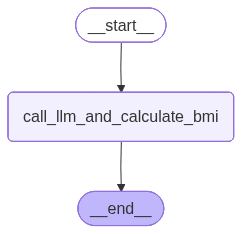

In [313]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())